<a href="https://colab.research.google.com/github/siskamr17-code/UTS-Data-Mining/blob/main/tugas2_datmin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving covid_19_clean_complete.csv to covid_19_clean_complete.csv


In [ ]:
df = pd.read_csv('covid_19_clean_complete.csv')

df.head()

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.93911,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.15330,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.03390,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.50630,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.20270,17.873900,2020-01-22,0,0,0,0,Africa


In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

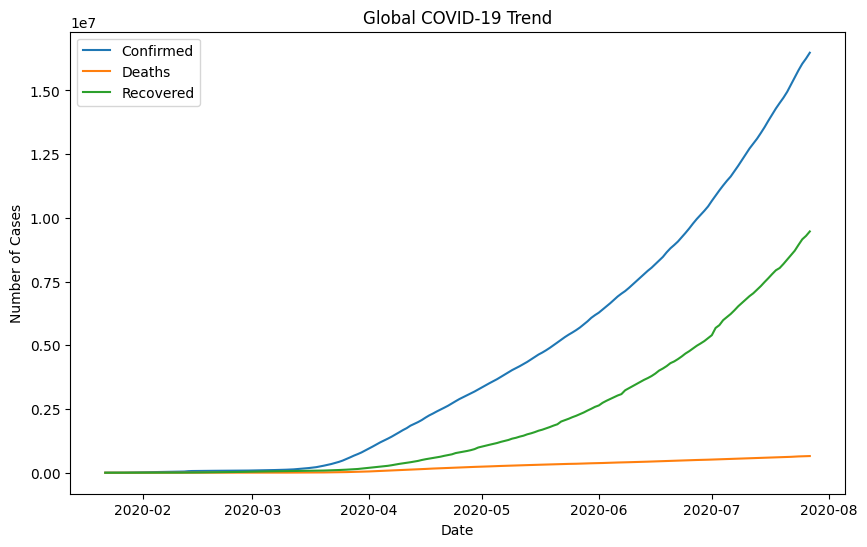

In [ ]:
global_data = df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

plt.figure(figsize=(10,6))
plt.plot(global_data.index, global_data['Confirmed'], label='Confirmed')
plt.plot(global_data.index, global_data['Deaths'], label='Deaths')
plt.plot(global_data.index, global_data['Recovered'], label='Recovered')

plt.title('Global COVID-19 Trend')
plt.xlabel('Date')
plt.ylabel('Number of Cases')
plt.legend()

plt.show()

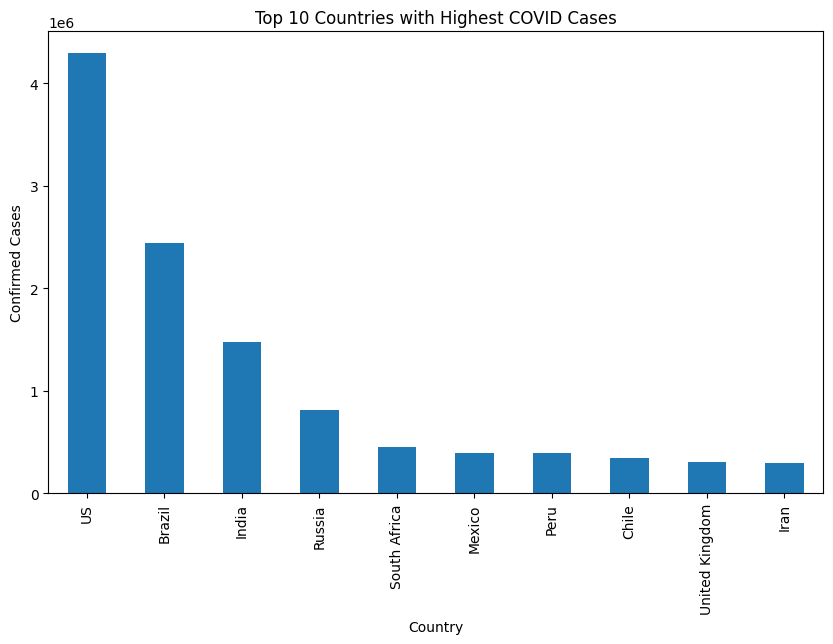

In [ ]:
latest = df[df['Date'] == df['Date'].max()]

top10 = latest.groupby('Country/Region')['Confirmed'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top10.plot(kind='bar')

plt.title('Top 10 Countries with Highest COVID Cases')
plt.xlabel('Country')
plt.ylabel('Confirmed Cases')

plt.show()

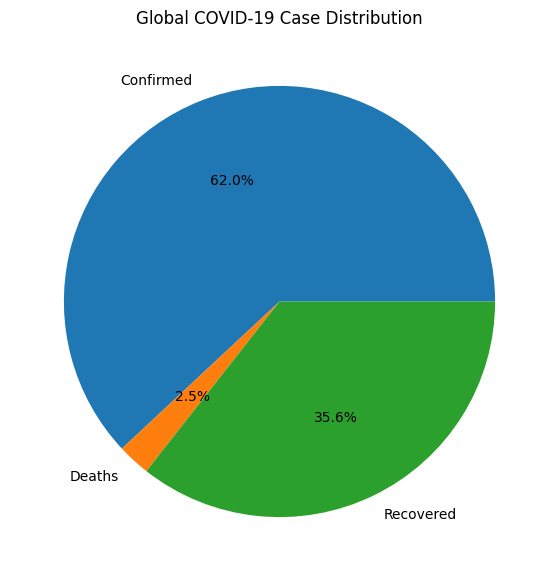

In [ ]:
latest_global = latest[['Confirmed','Deaths','Recovered']].sum()

plt.figure(figsize=(7,7))
plt.pie(latest_global,
        labels=latest_global.index,
        autopct='%1.1f%%')

plt.title('Global COVID-19 Case Distribution')

plt.show()

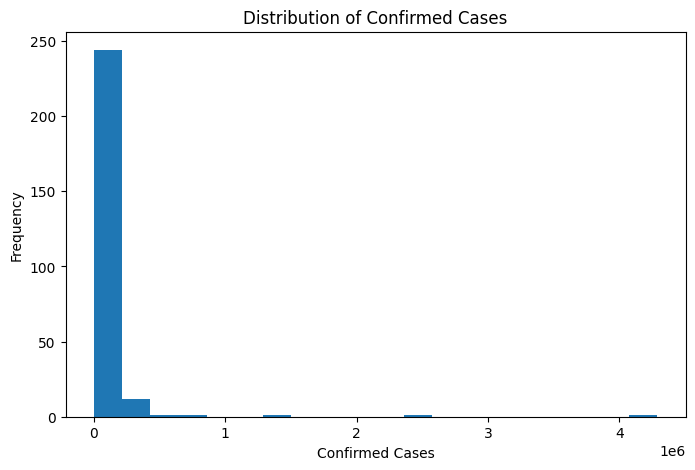

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(latest['Confirmed'], bins=20)

plt.title('Distribution of Confirmed Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Frequency')

plt.show()

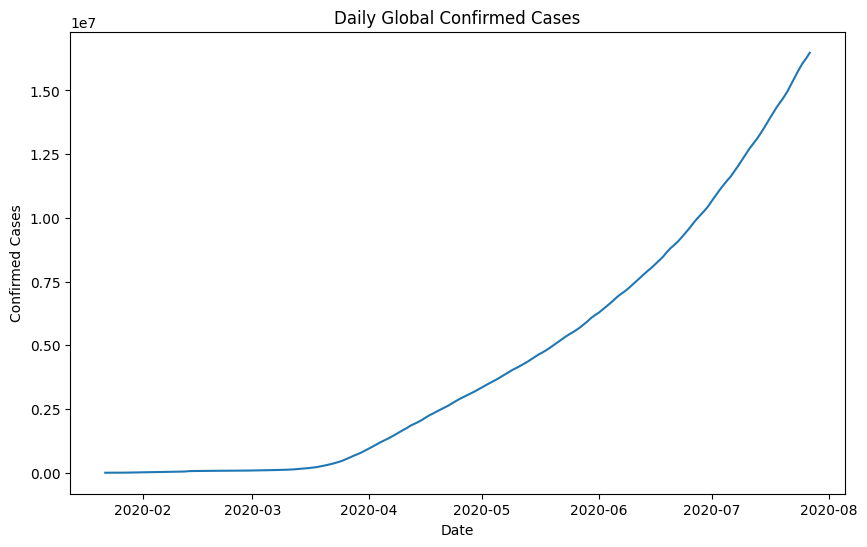

In [ ]:
daily_cases = df.groupby('Date')['Confirmed'].sum()

plt.figure(figsize=(10,6))
plt.plot(daily_cases.index, daily_cases.values)

plt.title('Daily Global Confirmed Cases')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')

plt.show()

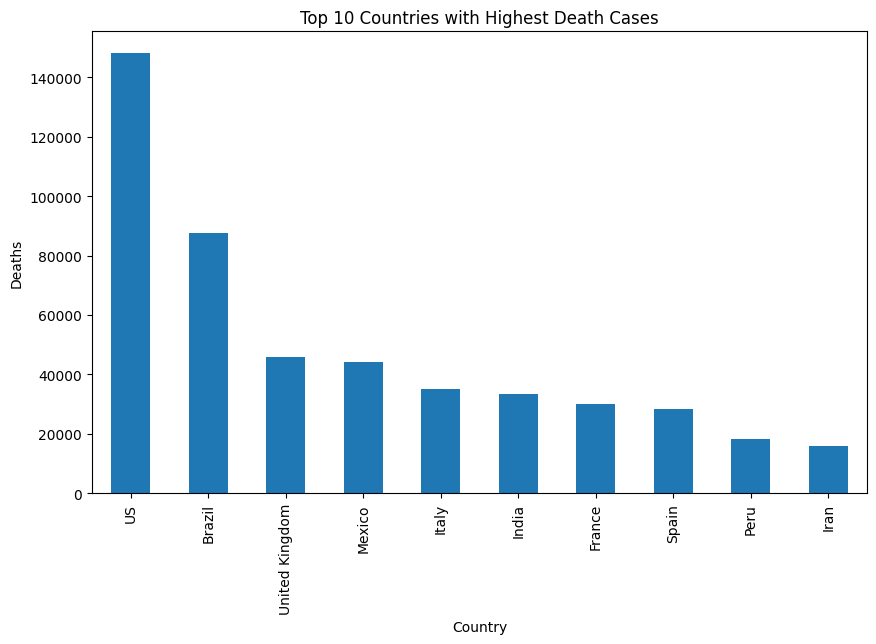

In [ ]:
latest = df[df['Date'] == df['Date'].max()]

top_deaths = latest.groupby('Country/Region')['Deaths'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_deaths.plot(kind='bar')

plt.title('Top 10 Countries with Highest Death Cases')
plt.xlabel('Country')
plt.ylabel('Deaths')

plt.show()

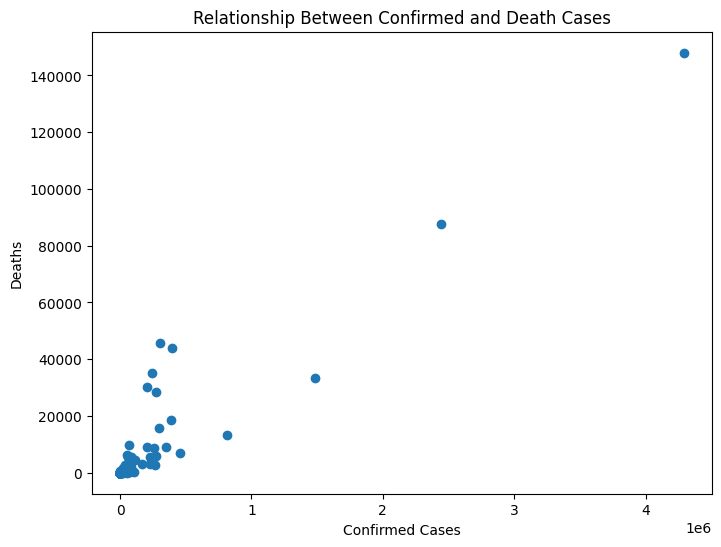

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(latest['Confirmed'], latest['Deaths'])

plt.title('Relationship Between Confirmed and Death Cases')
plt.xlabel('Confirmed Cases')
plt.ylabel('Deaths')

plt.show()

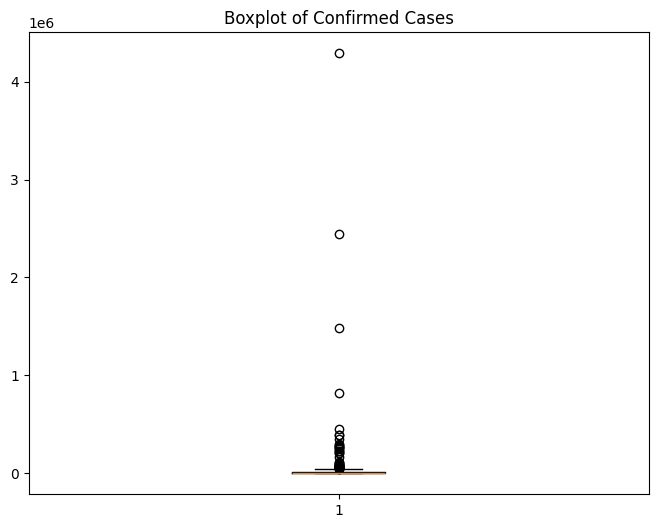

In [ ]:
plt.figure(figsize=(8,6))

plt.boxplot(latest['Confirmed'])

plt.title('Boxplot of Confirmed Cases')

plt.show()

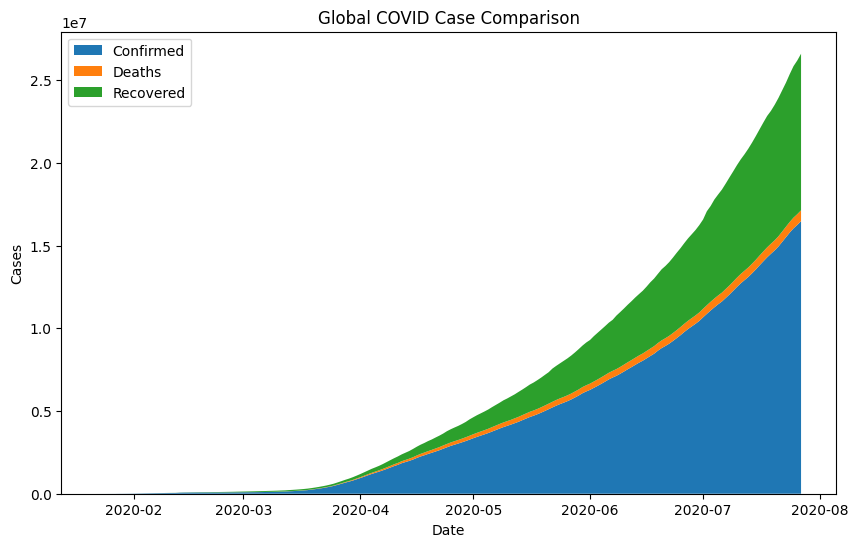

In [ ]:
global_data = df.groupby('Date')[['Confirmed','Deaths','Recovered']].sum()

plt.figure(figsize=(10,6))
plt.stackplot(global_data.index,
              global_data['Confirmed'],
              global_data['Deaths'],
              global_data['Recovered'],
              labels=['Confirmed','Deaths','Recovered'])

plt.legend(loc='upper left')
plt.title('Global COVID Case Comparison')
plt.xlabel('Date')
plt.ylabel('Cases')

plt.show()